## Forecast Generation — June 2026

The dataset contains actual overnight-stay records up to and including **May 2026**. Using this as the input, we generate forecasts for **June 2026** across all 47 prefectures. Weather inputs are derived from climatological averages (prefecture x month means from the training set), as actual June 2026 weather data is not yet available at time of writing.

## Data Loading

We load the tourism dataset containing prefecture-level monthly visitor counts along with weather variables.

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("data/final_tourism_weather_2007_2026.csv")


In [2]:
df = df.sort_values(["prefecture", "year", "month"]).reset_index(drop=True)

## Feature Engineering

We construct temporal, seasonal, and autoregressive features to capture tourism demand dynamics.

In [3]:
df["log_visitors"] = np.log1p(df["overnight_stays"])

In [4]:
# Temporal trend
df["year_trend"] = df["year"] - df["year"].min()
# df["year_trend_sq"] = df["year_trend"] ** 2

# Lag features — on log_visitors, grouped by prefecture
df["lag_1"]  = df.groupby("prefecture")["log_visitors"].shift(1)
df["lag_2"]  = df.groupby("prefecture")["log_visitors"].shift(2)
df["lag_6"]  = df.groupby("prefecture")["log_visitors"].shift(6)
df["lag_12"] = df.groupby("prefecture")["log_visitors"].shift(12)

# Rolling mean — shift(1) to avoid leakage
df["roll_3_mean"] = (
    df.groupby("prefecture")["log_visitors"]
    .shift(1)
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

# Cyclic encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# COVID structural break flag
df["covid_shock"] = ((df["year"] >= 2020) & (df["year"] <= 2021)).astype(int)

In [5]:
# Cultural calendar
df["cherry_blossom"] = df["month"].isin([3, 4]).astype(int)
df["golden_week"]    = df["month"].isin([4, 5]).astype(int)
df["obon"]           = df["month"].isin([8]).astype(int)

In [6]:
# ── Spillover: hub prefecture's lag_1 for each satellite prefecture ──
hub_map = {
    # Tokyo as hub → Kanto satellites
    "Ibaraki": "Tokyo", "Saitama": "Tokyo", "Chiba": "Tokyo",
    "Tochigi": "Tokyo", "Gunma": "Tokyo", "Kanagawa": "Tokyo", "Yamanashi": "Tokyo",
    # Osaka as hub → Kansai satellites
    "Kyoto": "Osaka", "Nara": "Osaka", "Hyogo": "Osaka",
    "Shiga": "Osaka", "Wakayama": "Osaka", "Mie": "Osaka",
    # Fukuoka as hub → Kyushu satellites
    "Saga": "Fukuoka", "Nagasaki": "Fukuoka", "Kumamoto": "Fukuoka",
    "Oita": "Fukuoka", "Miyazaki": "Fukuoka", "Kagoshima": "Fukuoka",
    # Hiroshima as hub → Chugoku satellites
    "Okayama": "Hiroshima", "Tottori": "Hiroshima",
    "Shimane": "Hiroshima", "Yamaguchi": "Hiroshima",
}

# Map each prefecture to its hub (default: itself)
df["hub_pref"] = df["prefecture"].map(hub_map).fillna(df["prefecture"])

# Build lookup of hub's lag_1 per (hub_pref, year, month)
hub_lags = (
    df[["prefecture", "year", "month", "lag_1"]]
    .rename(columns={"prefecture": "hub_pref", "lag_1": "hub_lag_1"})
)

# Merge hub's lag_1 onto every row
df = df.merge(hub_lags, on=["hub_pref", "year", "month"], how="left")
df = df.drop(columns=["hub_pref"])

print("hub_lag_1 added. Sample:")
print(df[df["prefecture"].isin(["Ibaraki", "Nara", "Tokyo", "Osaka"])][
    ["prefecture", "year", "month", "lag_1", "hub_lag_1"]].head(8))


hub_lag_1 added. Sample:
     prefecture  year  month     lag_1  hub_lag_1
3029    Ibaraki  2007      1       NaN        NaN
3030    Ibaraki  2007      2  8.658866  13.106053
3031    Ibaraki  2007      3  8.499233  13.205051
3032    Ibaraki  2007      4  8.945202  13.404426
3033    Ibaraki  2007      5  8.730852  13.524892
3034    Ibaraki  2007      6  8.414274  13.336121
3035    Ibaraki  2007      7  8.568076  13.358780
3036    Ibaraki  2007      8  8.742095  13.477238


## Geographic Features
New in this model: spatial encoding for all 47 prefectures.


In [7]:
import math

prefecture_geo = {
    "Hokkaido":  {"lat": 43.06, "lon": 141.35, "coastal": 1, "snow_region": 1, "intl_airport": 1},
    "Aomori":    {"lat": 40.82, "lon": 140.74, "coastal": 1, "snow_region": 1, "intl_airport": 0},
    "Iwate":     {"lat": 39.70, "lon": 141.13, "coastal": 1, "snow_region": 1, "intl_airport": 0},
    "Miyagi":    {"lat": 38.27, "lon": 140.87, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Akita":     {"lat": 39.72, "lon": 140.10, "coastal": 1, "snow_region": 1, "intl_airport": 0},
    "Yamagata":  {"lat": 38.24, "lon": 140.36, "coastal": 1, "snow_region": 1, "intl_airport": 0},
    "Fukushima": {"lat": 37.75, "lon": 140.47, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Ibaraki":   {"lat": 36.34, "lon": 140.45, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Tochigi":   {"lat": 36.57, "lon": 139.88, "coastal": 0, "snow_region": 0, "intl_airport": 0},
    "Gunma":     {"lat": 36.39, "lon": 139.06, "coastal": 0, "snow_region": 1, "intl_airport": 0},
    "Saitama":   {"lat": 35.86, "lon": 139.65, "coastal": 0, "snow_region": 0, "intl_airport": 0},
    "Chiba":     {"lat": 35.61, "lon": 140.12, "coastal": 1, "snow_region": 0, "intl_airport": 1},
    "Tokyo":     {"lat": 35.68, "lon": 139.69, "coastal": 1, "snow_region": 0, "intl_airport": 1},
    "Kanagawa":  {"lat": 35.45, "lon": 139.64, "coastal": 1, "snow_region": 0, "intl_airport": 1},
    "Niigata":   {"lat": 37.90, "lon": 139.02, "coastal": 1, "snow_region": 1, "intl_airport": 0},
    "Toyama":    {"lat": 36.70, "lon": 137.21, "coastal": 1, "snow_region": 1, "intl_airport": 0},
    "Ishikawa":  {"lat": 36.59, "lon": 136.63, "coastal": 1, "snow_region": 1, "intl_airport": 0},
    "Fukui":     {"lat": 36.07, "lon": 136.22, "coastal": 1, "snow_region": 1, "intl_airport": 0},
    "Yamanashi": {"lat": 35.66, "lon": 138.57, "coastal": 0, "snow_region": 0, "intl_airport": 0},
    "Nagano":    {"lat": 36.65, "lon": 138.18, "coastal": 0, "snow_region": 1, "intl_airport": 0},
    "Gifu":      {"lat": 35.39, "lon": 136.72, "coastal": 0, "snow_region": 1, "intl_airport": 0},
    "Shizuoka":  {"lat": 34.98, "lon": 138.38, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Aichi":     {"lat": 35.18, "lon": 136.91, "coastal": 1, "snow_region": 0, "intl_airport": 1},
    "Mie":       {"lat": 34.73, "lon": 136.51, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Shiga":     {"lat": 35.00, "lon": 135.87, "coastal": 0, "snow_region": 0, "intl_airport": 0},
    "Kyoto":     {"lat": 35.02, "lon": 135.76, "coastal": 0, "snow_region": 0, "intl_airport": 0},
    "Osaka":     {"lat": 34.69, "lon": 135.50, "coastal": 1, "snow_region": 0, "intl_airport": 1},
    "Hyogo":     {"lat": 34.69, "lon": 135.18, "coastal": 1, "snow_region": 0, "intl_airport": 1},
    "Nara":      {"lat": 34.68, "lon": 135.83, "coastal": 0, "snow_region": 0, "intl_airport": 0},
    "Wakayama":  {"lat": 34.23, "lon": 135.17, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Tottori":   {"lat": 35.50, "lon": 134.24, "coastal": 1, "snow_region": 1, "intl_airport": 0},
    "Shimane":   {"lat": 35.47, "lon": 133.05, "coastal": 1, "snow_region": 1, "intl_airport": 0},
    "Okayama":   {"lat": 34.66, "lon": 133.93, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Hiroshima": {"lat": 34.40, "lon": 132.46, "coastal": 1, "snow_region": 0, "intl_airport": 1},
    "Yamaguchi": {"lat": 34.19, "lon": 131.47, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Tokushima": {"lat": 34.07, "lon": 134.56, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Kagawa":    {"lat": 34.34, "lon": 134.04, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Ehime":     {"lat": 33.84, "lon": 132.77, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Kochi":     {"lat": 33.56, "lon": 133.53, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Fukuoka":   {"lat": 33.61, "lon": 130.42, "coastal": 1, "snow_region": 0, "intl_airport": 1},
    "Saga":      {"lat": 33.25, "lon": 130.30, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Nagasaki":  {"lat": 32.74, "lon": 129.87, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Kumamoto":  {"lat": 32.79, "lon": 130.74, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Oita":      {"lat": 33.24, "lon": 131.61, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Miyazaki":  {"lat": 31.91, "lon": 131.42, "coastal": 1, "snow_region": 0, "intl_airport": 0},
    "Kagoshima": {"lat": 31.56, "lon": 130.56, "coastal": 1, "snow_region": 0, "intl_airport": 1},
    "Okinawa":   {"lat": 26.21, "lon": 127.68, "coastal": 1, "snow_region": 0, "intl_airport": 1},
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

TOKYO_LAT, TOKYO_LON  = 35.68, 139.69
OSAKA_LAT,  OSAKA_LON = 34.69, 135.50

for col in ["lat", "lon", "coastal", "snow_region", "intl_airport"]:
    df[col] = df["prefecture"].map(lambda p: prefecture_geo[p][col])

df["dist_tokyo"] = df["prefecture"].map(
    lambda p: haversine(prefecture_geo[p]["lat"], prefecture_geo[p]["lon"], TOKYO_LAT, TOKYO_LON)
)
df["dist_osaka"] = df["prefecture"].map(
    lambda p: haversine(prefecture_geo[p]["lat"], prefecture_geo[p]["lon"], OSAKA_LAT, OSAKA_LON)
)

print("Geographic features added:", ["lat","lon","coastal","snow_region","intl_airport","dist_tokyo","dist_osaka"])


Geographic features added: ['lat', 'lon', 'coastal', 'snow_region', 'intl_airport', 'dist_tokyo', 'dist_osaka']


In [8]:
# lag_12 creates 12 NaN rows per prefecture at the start — drop all incomplete rows
df = df.dropna().reset_index(drop=True)

## Time-Aware Train-Test Split

We split the data chronologically to avoid leakage.

In [9]:
train = df[df["year"] <= 2023].copy()
val   = df[df["year"] == 2024].copy()
test  = df[df["year"].isin([2025, 2026])].copy()

print(f"Train: {train.shape} | Years: {train['year'].min()}-{train['year'].max()}")
print(f"Val   : {val.shape} | Years: {val['year'].min()}-{val['year'].max()}")
print(f"Test  : {test.shape} | Years: {test['year'].min()}-{test['year'].max()}")

Train: (9024, 29) | Years: 2008-2023
Val   : (564, 29) | Years: 2024-2024
Test  : (799, 29) | Years: 2025-2026


## Feature Selection

We select the final feature set used for model training.

In [10]:
features = [
    # ── Temporal ──
    "month_sin", "month_cos", 
    "year_trend",
    # "year_trend_sq",
    # ── Weather ──
    "temp_avg", "precip_sum",
    # ── Calendar ──
    "cherry_blossom", "golden_week", "obon", "covid_shock",
    # ── Autoregressive ──
    "lag_1", "lag_2", "lag_6", "lag_12", "roll_3_mean","hub_lag_1",
    # ── Geographic ──
    "lat", "lon", "coastal", "snow_region", "intl_airport",
    "dist_tokyo", "dist_osaka",
]

target = "log_visitors"  

X_train_raw = train[features].copy()
X_val_raw   = val[features].copy()
X_test_raw  = test[features].copy()

y_train = train["log_visitors"]
y_val   = val["log_visitors"]
y_test  = test["log_visitors"]

print(f"X_train_raw shape: {X_train_raw.shape}")
print(f"X_val_raw shape  : {X_val_raw.shape}")
print(f"X_test_raw shape : {X_test_raw.shape}")

X_train_raw shape: (9024, 22)
X_val_raw shape  : (564, 22)
X_test_raw shape : (799, 22)


### Target Encoding & Detrended Lag Features

We apply **Expanding Window Out-of-Fold (OOF) target encoding** to capture each prefecture's seasonal baseline without leaking future information into the training set. We also compute detrended lag features (`lag_1_detrend`, `lag_12_detrend`) to signal whether last month / last year was above or below the historical average for that prefecture-month pair.

In [11]:
# 1. Compute global dictionaries for Validation/Test/Future use
pref_month_mean_reg = train.groupby(["prefecture", "month"])["log_visitors"].mean().to_dict()
pref_month_std_reg = train.groupby(["prefecture", "month"])["log_visitors"].std().to_dict()

# 2. Initialize the columns with NaNs
X_train_raw["pref_month_enc"] = np.nan

# 3. Expanding Window OOF Target Encoding for Train Set (Prevents CV Leakage)
years_sorted = sorted(train["year"].unique())
for yr in years_sorted:
    past_mask = train["year"] < yr
    current_mask = train["year"] == yr

    if past_mask.sum() == 0:
        # No prior years exist — fall back to THIS year's cross-prefecture average per month.
        # Uses only same-year data, never a future year, never the full-train mean.
        same_year_month_means = train[current_mask].groupby("month")["log_visitors"].mean().to_dict()
        X_train_raw.loc[current_mask, "pref_month_enc"] = train[current_mask]["month"].map(same_year_month_means)
        continue

    past_means = train[past_mask].groupby(["prefecture", "month"])["log_visitors"].mean().to_dict()
    past_overall_mean = train[past_mask]["log_visitors"].mean()   # past-only fallback, not the full-train mean

    X_train_raw.loc[current_mask, "pref_month_enc"] = train[current_mask].apply(
        lambda row: past_means.get((row["prefecture"], row["month"]), past_overall_mean), axis=1
    )

# 4. Map global dictionaries for Val and Test sets (Safe, as this is past data relative to them)
X_val_raw["pref_month_enc"] = val.apply(
    lambda row: pref_month_mean_reg.get((row["prefecture"], row["month"]), 0), axis=1
)
X_test_raw["pref_month_enc"] = test.apply(
    lambda row: pref_month_mean_reg.get((row["prefecture"], row["month"]), 0), axis=1
)

# Keep your existing seasonal_deviation initialization below this
X_train_raw["seasonal_deviation"] = 0
X_val_raw["seasonal_deviation"] = 0
X_test_raw["seasonal_deviation"] = 0

X_train = X_train_raw.copy()
X_val   = X_val_raw.copy()
X_test  = X_test_raw.copy()

# ── Detrended lags: how far above/below historical average was each lag ──

# lag_12_detrend: lag_12 is the same month previous year → subtract that month's mean
X_train_raw["lag_12_detrend"] = train["lag_12"] - train.apply(
    lambda r: pref_month_mean_reg.get((r["prefecture"], r["month"]), 0), axis=1
)
X_val_raw["lag_12_detrend"] = val["lag_12"] - val.apply(
    lambda r: pref_month_mean_reg.get((r["prefecture"], r["month"]), 0), axis=1
)
X_test_raw["lag_12_detrend"] = test["lag_12"] - test.apply(
    lambda r: pref_month_mean_reg.get((r["prefecture"], r["month"]), 0), axis=1
)

# lag_1_detrend: lag_1 is previous month → subtract previous month's mean
def prev_month_enc(r):
    prev_m = r["month"] - 1 if r["month"] > 1 else 12
    return pref_month_mean_reg.get((r["prefecture"], prev_m), 0)

X_train_raw["lag_1_detrend"] = train["lag_1"] - train.apply(prev_month_enc, axis=1)
X_val_raw["lag_1_detrend"]   = val["lag_1"]   - val.apply(prev_month_enc, axis=1)
X_test_raw["lag_1_detrend"]  = test["lag_1"]  - test.apply(prev_month_enc, axis=1)

# Re-assign so X_train/X_val/X_test pick up the new columns
X_train = X_train_raw.copy()
X_val   = X_val_raw.copy()
X_test  = X_test_raw.copy()

print("Detrended lags added. New feature count:", X_train.shape[1])

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape  : {X_val.shape}")
print(f"X_test shape : {X_test.shape}")

Detrended lags added. New feature count: 26
X_train shape: (9024, 26)
X_val shape  : (564, 26)
X_test shape : (799, 26)


### Pass-1 Model: Seasonal Deviation Feature

A lightweight CatBoost model (Pass 1) is trained using time-aware expanding-window cross-validation to generate OOF predictions on the training set. These predictions are normalised into a **seasonal deviation** z-score — how many standard deviations above/below the prefecture-month mean the model expects — and added as an additional feature for the final model.

In [12]:
from catboost import CatBoostRegressor

features_pass1 = [c for c in X_train.columns if c != "seasonal_deviation"]

# simple params — deliberately independent of best_params_cb, which isn't defined yet.
pass1_params_cb = dict(depth=6, learning_rate=0.05, iterations=300, l2_leaf_reg=3, random_state=42)

train_preds_log = pd.Series(index=X_train.index, dtype=float)
years_sorted = sorted(train["year"].unique())
for y in years_sorted[1:]:
    train_mask   = train["year"] < y
    predict_mask = train["year"] == y
    if train_mask.sum() == 0 or predict_mask.sum() == 0:
        continue
    fold_model = CatBoostRegressor(loss_function="RMSE", verbose=0, **pass1_params_cb)
    fold_model.fit(X_train.loc[train_mask, features_pass1], y_train.loc[train_mask])
    train_preds_log.loc[predict_mask] = fold_model.predict(X_train.loc[predict_mask, features_pass1])

first_year_mask = train["year"] == years_sorted[0]
train_preds_log.loc[first_year_mask] = X_train.loc[first_year_mask, "pref_month_enc"]

pass1_model = CatBoostRegressor(loss_function="RMSE", verbose=0, **pass1_params_cb)
pass1_model.fit(X_train[features_pass1], y_train)

def build_seasonal_deviation(df_split, preds_log):
    means = df_split.apply(lambda r: pref_month_mean_reg.get((r["prefecture"], r["month"]), 0), axis=1).values
    stds  = df_split.apply(lambda r: max(pref_month_std_reg.get((r["prefecture"], r["month"]), 1), 1e-6), axis=1).values
    return (preds_log - means) / stds

X_train["seasonal_deviation"] = build_seasonal_deviation(train, train_preds_log.values)
X_val["seasonal_deviation"]   = build_seasonal_deviation(val,  pass1_model.predict(X_val[features_pass1]))
X_test["seasonal_deviation"]  = build_seasonal_deviation(test, pass1_model.predict(X_test[features_pass1]))

### Data Sanity Checks

We assert that all feature matrices are NaN-free, have matching column schemas, and contain the expected number of features before training begins.

In [13]:
assert X_train.isnull().sum().sum() == 0, "NaN found in X_train"
assert X_val.isnull().sum().sum() == 0, "NaN found in X_val"
assert X_test.isnull().sum().sum() == 0, "NaN found in X_test"
assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), "Column mismatch"
assert X_train.shape[1] == 26, f"Expected 23 features, got {X_train.shape[1]}"

print(" No NaN in X_train, X_val, or X_test")
print(" Column schemas match across all three splits")
print(f" Feature count: {X_train.shape[1]}")
print(f" y_train range: {y_train.min():.3f} to {y_train.max():.3f}, mean: {y_train.mean():.3f}")
print(f" y_val   range: {y_val.min():.3f} to {y_val.max():.3f}, mean: {y_val.mean():.3f}")
print(f" y_test  range: {y_test.min():.3f} to {y_test.max():.3f}, mean: {y_test.mean():.3f}")
print(X_train.columns.tolist())

 No NaN in X_train, X_val, or X_test
 Column schemas match across all three splits
 Feature count: 26
 y_train range: 9.858 to 15.460, mean: 12.956
 y_val   range: 11.629 to 15.488, mean: 13.209
 y_test  range: 11.605 to 15.485, mean: 13.200
['month_sin', 'month_cos', 'year_trend', 'temp_avg', 'precip_sum', 'cherry_blossom', 'golden_week', 'obon', 'covid_shock', 'lag_1', 'lag_2', 'lag_6', 'lag_12', 'roll_3_mean', 'hub_lag_1', 'lat', 'lon', 'coastal', 'snow_region', 'intl_airport', 'dist_tokyo', 'dist_osaka', 'pref_month_enc', 'seasonal_deviation', 'lag_12_detrend', 'lag_1_detrend']


## Experiment: XGBoost (Discarded)

XGBoost was the first algorithm evaluated under the same feature set and time-aware cross-validation framework. After tuning depth, learning rate, regularisation, and min_child_weight via `RandomizedSearchCV`, it was outperformed by CatBoost on validation RMSE. All code is preserved below for reference but is **not executed** in the final run.

In [43]:
# from xgboost import XGBRegressor
# from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
# from sklearn.metrics import mean_squared_error, mean_absolute_error
# from sklearn.model_selection import RandomizedSearchCV

# # --- Proper time-aware CV folds (fixes prefecture-mixed TimeSeriesSplit) ---
# train_years = train["year"].values  # aligned by row position with X_train/y_train

# def make_time_folds(years_array, cutoffs=[2018, 2019, 2020, 2021, 2022]):
#     folds = []
#     for cutoff in cutoffs:
#         train_idx = np.where(years_array <= cutoff)[0]
#         val_idx   = np.where(years_array == cutoff + 1)[0]
#         folds.append((train_idx, val_idx))
#     return folds

# time_folds = make_time_folds(train_years)

# param_grid = {
#     "max_depth"        : [5, 6, 7],
#     "learning_rate"    : [0.01, 0.03],
#     "n_estimators"     : [300, 500],
#     # "subsample"        : [0.8, 1.0],
#     # "colsample_bytree" : [0.8, 1.0],
#     # "gamma"            : [0, 0.1],
#     "min_child_weight" : [1, 3, 5],
#     "reg_alpha"        : [0, 0.1, 0.5],   # L1 — encourages sparser splits
#     "reg_lambda"       : [1, 2, 5],       # L2 — penalizes large leaf weights, already default=1
# }

# # tscv = TimeSeriesSplit(n_splits=3)

# xgb_reg = XGBRegressor(
#     subsample=1.0, 
#     colsample_bytree=1.0, 
#     gamma=0.1,
#     random_state=42
# )

# random_search = RandomizedSearchCV(
#     estimator=xgb_reg,
#     param_distributions=param_grid,  # Your exact grid from above
#     n_iter=300,                      # Only try 300 random combinations!
#     cv=time_folds,
#     scoring='neg_mean_squared_error',
#     verbose=1,                       # Shows progress
#     n_jobs=-1,                       # Uses all CPU cores
#     random_state=42
# )
# random_search.fit(X_train, y_train)
# # grid_reg = GridSearchCV(
# #     estimator=xgb_reg,
# #     param_grid=param_grid,
# #     scoring="neg_root_mean_squared_error",
# #     cv=time_folds,
# #     n_jobs=-1,
# #     verbose=0
# # )

# # grid_reg.fit(X_train, y_train)

# # best_reg_model = grid_reg.best_estimator_
# best_reg_model = random_search.best_estimator_
# print(f"Best Params: {random_search.best_params_}")
# print(f"Best CV RMSE (log scale): {-random_search.best_score_:.4f}")

# # Validation check — first time this model sees 2024
# val_preds = best_reg_model.predict(X_val)
# val_rmse  = np.sqrt(mean_squared_error(y_val, val_preds))
# val_mae   = mean_absolute_error(y_val, val_preds)
# print(f"Validation RMSE (2024, log scale): {val_rmse:.4f}")
# print(f"Validation MAE  (2024, log scale): {val_mae:.4f}")

#### XGBoost — Final Test Evaluation (2025 & 2026)

The test evaluation code below was used during XGBoost experimentation. It is preserved for completeness but commented out as XGBoost was not selected as the final model.

In [44]:
# preds_log = best_reg_model.predict(X_test)
# rmse_log  = np.sqrt(mean_squared_error(y_test, preds_log))
# mae_log   = mean_absolute_error(y_test, preds_log)

# print(f"Test RMSE (log scale): {rmse_log:.4f}")
# print(f"Test MAE  (log scale): {mae_log:.4f}")

# # Back-transform to real scale for interpretability
# preds_actual   = np.expm1(preds_log + (rmse_log**2 / 2))
# y_test_actual  = np.expm1(y_test)
# rmse_actual    = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
# mae_actual     = mean_absolute_error(y_test_actual, preds_actual)

# print(f"Test RMSE (actual visitors): {rmse_actual:,.0f}")
# print(f"Test MAE  (actual visitors): {mae_actual:,.0f}")

#### XGBoost — SHAP Feature Importance

SHAP analysis was planned for the XGBoost model to compare feature importances. This code is preserved for reference but was never used in production since XGBoost was discarded. See the CatBoost SHAP section below for the active analysis.

In [45]:
# import shap

# explainer_reg = shap.TreeExplainer(best_reg_model)
# shap_values_reg = explainer_reg.shap_values(X_test)

# shap_explanation_reg = shap.Explanation(
#     values=shap_values_reg,
#     data=X_test,
#     feature_names=X_test.columns.tolist()
# )

# shap.plots.beeswarm(shap_explanation_reg, show=False)


In [46]:
# shap.plots.bar(shap_explanation_reg, show=False)

In [47]:
# print(dict(zip(X_test.columns, np.abs(shap_values_reg).mean(axis=0))))

## CatBoost Model

We compare performance using CatBoost under the same feature setup.

In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error
from catboost import CatBoostRegressor
import itertools
import numpy as np

# --- Proper time-aware CV folds (fixes prefecture-mixed TimeSeriesSplit) ---
train_years = train["year"].values  

def make_time_folds(years_array, cutoffs=[2018, 2019, 2020, 2021, 2022]):
    folds = []
    for cutoff in cutoffs:
        train_idx = np.where(years_array <= cutoff)[0]
        val_idx   = np.where(years_array == cutoff + 1)[0]
        folds.append((train_idx, val_idx))
    return folds

time_folds = make_time_folds(train_years)

cb_param_grid = {
    "depth":         [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05],
    "iterations":    [500, 800, 1000],
    "l2_leaf_reg":   [0.5, 1, 3],
}

param_combos = list(itertools.product(*cb_param_grid.values()))
param_keys = list(cb_param_grid.keys())

best_rmse = float("inf")
best_params_cb = None

for combo in param_combos:
    params = dict(zip(param_keys, combo))
    fold_rmses = []

    for train_idx, val_idx in time_folds:
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(loss_function="RMSE", random_state=42, verbose=0, **params)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)
        fold_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))

    mean_rmse = np.mean(fold_rmses)
    if mean_rmse < best_rmse:
        best_rmse = mean_rmse
        best_params_cb = params

print(f"Best Params: {best_params_cb}")
print(f"Best CV RMSE (log scale): {best_rmse:.4f}")

best_cb_model = CatBoostRegressor(loss_function="RMSE", random_state=42, verbose=0, **best_params_cb)
best_cb_model.fit(X_train, y_train)

# --- Calculate Smearing Estimator ONCE from Train Data ---
train_preds_log = best_cb_model.predict(X_train)
smear_factor_cb = np.mean(np.exp(y_train - train_preds_log))
print(f"CatBoost Smear Factor derived from train: {smear_factor_cb:.4f}")

val_preds_cb = best_cb_model.predict(X_val)
val_rmse_cb  = np.sqrt(mean_squared_error(y_val, val_preds_cb))
print(f"Validation RMSE (2024, log scale): {val_rmse_cb:.4f}")

test_preds_cb = best_cb_model.predict(X_test)
test_rmse_cb  = np.sqrt(mean_squared_error(y_test, test_preds_cb))
test_mae_cb   = mean_absolute_error(y_test, test_preds_cb)
print(f"Test RMSE (2025 + 2026, log scale): {test_rmse_cb:.4f}")
print(f"Test MAE  (2025 + 2026, log scale): {test_mae_cb:.4f}")

# Apply expm1 with Duan's Smearing variance correction using CatBoost's log error
preds_actual_cb = smear_factor_cb * np.expm1(test_preds_cb)
y_test_actual_cb = np.expm1(y_test)

rmse_actual_cb = np.sqrt(mean_squared_error(y_test_actual_cb, preds_actual_cb))
mae_actual_cb = mean_absolute_error(y_test_actual_cb, preds_actual_cb)

print(f"Test RMSE (actual visitors): {rmse_actual_cb:,.0f}")
print(f"Test MAE (actual visitors): {mae_actual_cb:,.0f}")

Best Params: {'depth': 8, 'learning_rate': 0.05, 'iterations': 800, 'l2_leaf_reg': 0.5}
Best CV RMSE (log scale): 0.2480
CatBoost Smear Factor derived from train: 1.0009
Validation RMSE (2024, log scale): 0.0778
Test RMSE (2025 + 2026, log scale): 0.0803
Test MAE  (2025 + 2026, log scale): 0.0645
Test RMSE (actual visitors): 107,132
Test MAE (actual visitors): 55,565


### SHAP Feature Importance (CatBoost)

We use SHAP (SHapley Additive exPlanations) to interpret which features drive the CatBoost model's predictions. The beeswarm plot shows both the direction and magnitude of each feature's influence across all test samples.

<Axes: xlabel='SHAP value (impact on model output)'>

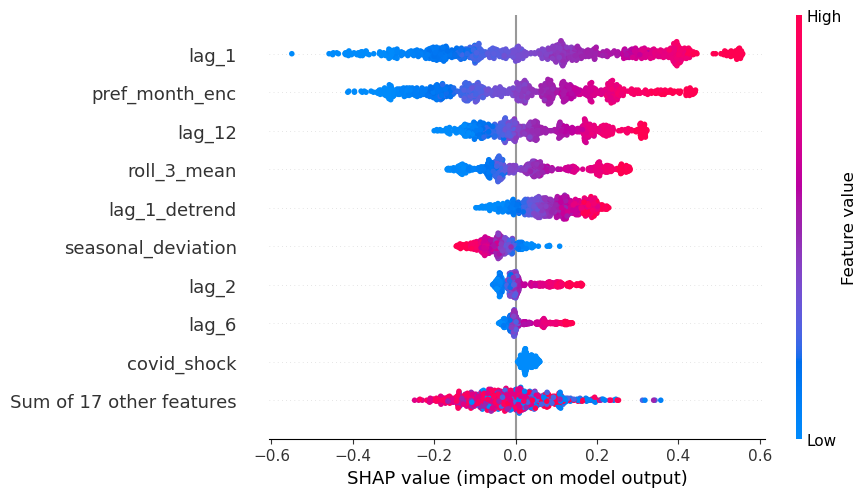

In [15]:
import shap

explainer_cb = shap.TreeExplainer(best_cb_model)
shap_values_cb = explainer_cb.shap_values(X_test)

shap_explanation_cb = shap.Explanation(
    values=shap_values_cb,
    data=X_test,
    feature_names=X_test.columns.tolist()
)

shap.plots.beeswarm(shap_explanation_cb, show=False)


<Axes: xlabel='mean(|SHAP value|)'>

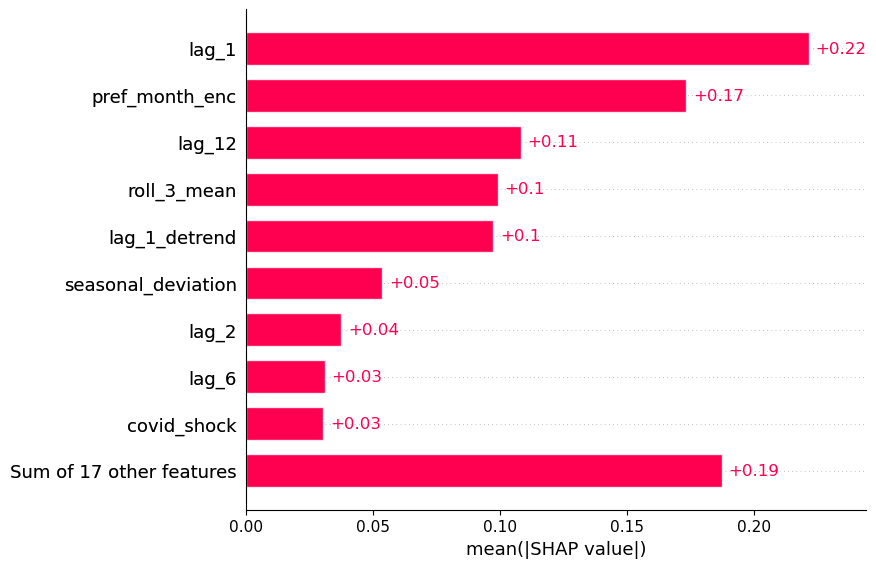

In [16]:
shap.plots.bar(shap_explanation_cb, show=False)

In [17]:
print(dict(zip(X_test.columns, np.abs(shap_values_cb).mean(axis=0))))

{'month_sin': np.float64(0.02890344532891641), 'month_cos': np.float64(0.011881208707669145), 'year_trend': np.float64(0.015713166758941532), 'temp_avg': np.float64(0.02410291396782351), 'precip_sum': np.float64(0.006179461753242378), 'cherry_blossom': np.float64(0.003403972829268279), 'golden_week': np.float64(0.004119305732145326), 'obon': np.float64(0.011417538103965386), 'covid_shock': np.float64(0.030359536501624162), 'lag_1': np.float64(0.2217045617601734), 'lag_2': np.float64(0.03737784006470062), 'lag_6': np.float64(0.03091537501692781), 'lag_12': np.float64(0.10831828924328155), 'roll_3_mean': np.float64(0.09912949809656951), 'hub_lag_1': np.float64(0.023398574634323318), 'lat': np.float64(0.00576233291788329), 'lon': np.float64(0.0035544550633329268), 'coastal': np.float64(0.0015410864505488134), 'snow_region': np.float64(0.0007054898097059194), 'intl_airport': np.float64(0.00886883975395799), 'dist_tokyo': np.float64(0.009750462263551784), 'dist_osaka': np.float64(0.00276271

## Experiment: Ensemble Models (Discarded)

Three ensemble strategies were explored to combine XGBoost and CatBoost:
1. **Simple average** — equal weighting of both models
2. **Weighted average** — more weight to CatBoost (better standalone RMSE)
3. **Scipy-optimised weighting** — minimising validation RMSE

None of the ensembles outperformed the standalone CatBoost model by a meaningful margin. Given the added complexity with negligible gain, CatBoost alone was selected as the final model. Code is preserved below for reference.

In [65]:
# # Simple average ensemble — equal weighting
# # ensemble_preds_log = (preds_log + test_preds_cb) / 2
# ensemble_preds_log    = 0.3 * preds_log + 0.7 * test_preds_cb

# # Evaluate on log scale
# ensemble_rmse_log = np.sqrt(mean_squared_error(y_test, ensemble_preds_log))
# ensemble_mae_log  = mean_absolute_error(y_test, ensemble_preds_log)

# print(f"Ensemble Test RMSE (log scale): {ensemble_rmse_log:.4f}")
# print(f"Ensemble Test MAE  (log scale): {ensemble_mae_log:.4f}")

# # Back-transform to actual visitor scale
# ensemble_preds_actual = np.expm1(ensemble_preds_log)
# y_test_actual         = np.expm1(y_test)

# ensemble_rmse_actual = np.sqrt(mean_squared_error(y_test_actual, ensemble_preds_actual))
# ensemble_mae_actual  = mean_absolute_error(y_test_actual, ensemble_preds_actual)

# print(f"Ensemble Test RMSE (actual visitors): {ensemble_rmse_actual:,.0f}")
# print(f"Ensemble Test MAE  (actual visitors): {ensemble_mae_actual:,.0f}")

In [66]:
# # Weighted ensemble — more weight to CatBoost (better standalone validation RMSE)
# weight_options = [
#     (0.6, 0.4),
#     (0.5, 0.5),   # equal — baseline you already have
#     (0.4, 0.6),   # slight CatBoost favor
#     (0.3, 0.7),   # stronger CatBoost favor
#     (0.2, 0.8),   # heavy CatBoost favor
# ]

# print(f"{'XGB Weight':<12}{'CB Weight':<12}{'RMSE (log)':<14}{'MAE (log)':<12}")
# print("-" * 50)

# for w_xgb, w_cb in weight_options:
#     blend_log = (w_xgb * preds_log) + (w_cb * test_preds_cb)

#     rmse_log = np.sqrt(mean_squared_error(y_test, blend_log))
#     mae_log  = mean_absolute_error(y_test, blend_log)

#     print(f"{w_xgb:<12}{w_cb:<12}{rmse_log:<14.4f}{mae_log:<12.4f}")


In [67]:
# from scipy.optimize import minimize_scalar

# # Get validation predictions from both models
# val_preds_xgb = best_reg_model.predict(X_val)
# val_preds_cb  = best_cb_model.predict(X_val)

# def blend_rmse(w_xgb):
#     blend = w_xgb * val_preds_xgb + (1 - w_xgb) * val_preds_cb
#     return np.sqrt(mean_squared_error(y_val, blend))

# result = minimize_scalar(blend_rmse, bounds=(0, 1), method="bounded")
# optimal_w_xgb = result.x
# optimal_w_cb  = 1 - optimal_w_xgb

# print(f"Optimal XGBoost weight: {optimal_w_xgb:.3f}")
# print(f"Optimal CatBoost weight: {optimal_w_cb:.3f}")
# print(f"Validation RMSE at optimal weights: {result.fun:.4f}")

# # Now apply this optimal weight to test set
# final_blend_log = optimal_w_xgb * preds_log + optimal_w_cb * test_preds_cb
# final_rmse_log = np.sqrt(mean_squared_error(y_test, final_blend_log))
# final_mae_log  = mean_absolute_error(y_test, final_blend_log)
# print(f"Test RMSE at optimal weights: {final_rmse_log:.4f}")
# print(f"Test MAE  at optimal weights: {final_mae_log:.4f}")

## Model Evaluation — Per-Prefecture RMSE (2025–2026)

We break down the CatBoost model's test error by individual prefecture to understand geographic performance variation. This helps identify which regions the model struggles with and can guide future feature additions (e.g. local event data, regional economic indicators).

In [18]:
# ── Per-Prefecture RMSE on 2025 Test Set ──
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Use the existing best_cb_model (CatBoost)
preds_cb_log  = best_cb_model.predict(X_test)

diag = test[["prefecture", "month", "overnight_stays"]].copy()
diag["actual_log"]   = y_test.values
diag["pred_cb_log"] = preds_cb_log

per_pref_rmse = (
    diag.groupby("prefecture")
    .apply(lambda g: np.sqrt(mean_squared_error(g["actual_log"], g["pred_cb_log"])))
    .reset_index()
    .rename(columns={0: "rmse_log"})
    .sort_values("rmse_log", ascending=False)
)

# Fixed the label here to say CatBoost instead of Ensemble
print("Per-Prefecture RMSE (CatBoost, 2025 and 2026 Test, log scale)")
print(per_pref_rmse.to_string(index=False))

Per-Prefecture RMSE (CatBoost, 2025 and 2026 Test, log scale)
prefecture  rmse_log
      Saga  0.117693
     Kyoto  0.116768
  Kanagawa  0.114859
   Okinawa  0.112496
  Ishikawa  0.106346
     Osaka  0.106117
     Tokyo  0.100840
   Ibaraki  0.098103
    Toyama  0.097445
 Tokushima  0.096826
  Miyazaki  0.091369
   Tochigi  0.088882
    Kagawa  0.087519
   Fukuoka  0.087282
      Nara  0.084566
     Fukui  0.083863
     Gunma  0.083839
     Akita  0.083330
 Yamaguchi  0.081152
   Shimane  0.081030
  Hokkaido  0.079965
   Tottori  0.079878
    Aomori  0.078263
  Wakayama  0.075503
     Kochi  0.074471
     Shiga  0.073224
     Hyogo  0.072973
   Niigata  0.072550
   Okayama  0.071528
 Yamanashi  0.070508
     Aichi  0.067194
    Nagano  0.065749
  Nagasaki  0.065436
      Oita  0.064978
 Kagoshima  0.064726
      Gifu  0.063063
  Shizuoka  0.062519
  Kumamoto  0.061483
 Hiroshima  0.059425
     Ehime  0.058586
       Mie  0.057415
   Saitama  0.057122
    Miyagi  0.055024
  Yamagata  0.

## Forecast Generation — June 2026

We generate overnight-stay forecasts for **June 2026** across all 47 prefectures. Weather inputs are derived from climatological averages (prefecture × month means from the training set), as actual June 2026 weather data is not yet available at the time of writing.

In [19]:
# Climatological weather average per (prefecture, month), from train only
pref_month_temp_avg = (
    train.groupby(["prefecture", "month"])["temp_avg"]
    .mean()
    .to_dict()
)
pref_month_precip_avg = (
    train.groupby(["prefecture", "month"])["precip_sum"]
    .mean()
    .to_dict()
)

print("Climatological weather averages computed")

Climatological weather averages computed


In [20]:
import pandas as pd
import numpy as np
from datetime import date
from dateutil.relativedelta import relativedelta

# ── One big known-stays lookup for ALL prefectures: real history ──
known_stays_all = {}
for _, row in df.iterrows():
    known_stays_all[(row["prefecture"], int(row["year"]), int(row["month"]))] = row["overnight_stays"]

def get_stays_all_fn(pref, y, m):
    return known_stays_all.get((pref, y, m), None)

months_to_predict = [(2026, 6)]
results_cb = []

for (yr, mo) in months_to_predict:             
    ref = date(yr, mo, 1)

    for TARGET_PREFECTURE in df["prefecture"].unique():

        def get_stays(y, m):
            return get_stays_all_fn(TARGET_PREFECTURE, y, m)

        lag_1  = get_stays((ref - relativedelta(months=1)).year,  (ref - relativedelta(months=1)).month)
        lag_2  = get_stays((ref - relativedelta(months=2)).year,  (ref - relativedelta(months=2)).month)
        lag_6  = get_stays((ref - relativedelta(months=6)).year,  (ref - relativedelta(months=6)).month)
        lag_12 = get_stays((ref - relativedelta(months=12)).year, (ref - relativedelta(months=12)).month)

        m1 = get_stays((ref - relativedelta(months=1)).year, (ref - relativedelta(months=1)).month)
        m2 = get_stays((ref - relativedelta(months=2)).year, (ref - relativedelta(months=2)).month)
        m3 = get_stays((ref - relativedelta(months=3)).year, (ref - relativedelta(months=3)).month)
        roll_3_mean = np.nanmean([x for x in [m1, m2, m3] if x is not None])

        month_sin  = np.sin(2 * np.pi * mo / 12)
        month_cos  = np.cos(2 * np.pi * mo / 12)
        year_trend = yr - df["year"].min()
        cherry_blossom = int(mo in [3, 4])
        golden_week    = int(mo in [4, 5])
        obon           = int(mo == 8)
        covid_shock    = 0

        temp_avg       = pref_month_temp_avg.get((TARGET_PREFECTURE, mo), 15.0)
        precip_sum     = pref_month_precip_avg.get((TARGET_PREFECTURE, mo), 100.0)
        pref_month_enc = pref_month_mean_reg.get((TARGET_PREFECTURE, mo), 0)

        def to_log(x):
            return np.log1p(x) if x is not None else pref_month_enc

        # hub_lag_1: looked up dynamically
        hub_pref = hub_map.get(TARGET_PREFECTURE, TARGET_PREFECTURE)
        hub_prev_ref = ref - relativedelta(months=1)
        hub_prev_val = get_stays_all_fn(hub_pref, hub_prev_ref.year, hub_prev_ref.month)
        hub_lag_1_val = to_log(hub_prev_val)

        # detrend reference month — dynamic
        prev_m_for_lag1_detrend = mo - 1 if mo > 1 else 12

        row_features = {
            "month_sin": month_sin, "month_cos": month_cos,
            "year_trend": year_trend,
            "temp_avg": temp_avg, "precip_sum": precip_sum,
            "cherry_blossom": cherry_blossom, "golden_week": golden_week,
            "obon": obon, "covid_shock": covid_shock,
            "lag_1":  to_log(lag_1),  "lag_2":  to_log(lag_2),
            "lag_6":  to_log(lag_6),  "lag_12": to_log(lag_12),
            "roll_3_mean": np.log1p(roll_3_mean) if roll_3_mean else pref_month_enc,
            "lat":          prefecture_geo[TARGET_PREFECTURE]["lat"],
            "lon":          prefecture_geo[TARGET_PREFECTURE]["lon"],
            "coastal":      prefecture_geo[TARGET_PREFECTURE]["coastal"],
            "snow_region":  prefecture_geo[TARGET_PREFECTURE]["snow_region"],
            "intl_airport": prefecture_geo[TARGET_PREFECTURE]["intl_airport"],
            "dist_tokyo":   haversine(prefecture_geo[TARGET_PREFECTURE]["lat"],
                                      prefecture_geo[TARGET_PREFECTURE]["lon"],
                                      TOKYO_LAT, TOKYO_LON),
            "dist_osaka":   haversine(prefecture_geo[TARGET_PREFECTURE]["lat"],
                                      prefecture_geo[TARGET_PREFECTURE]["lon"],
                                      OSAKA_LAT, OSAKA_LON),
            "pref_month_enc":     pref_month_enc,
            "seasonal_deviation": 0,                                     # placeholder pass 1
            "hub_lag_1":          hub_lag_1_val,
            "lag_12_detrend":     to_log(lag_12) - pref_month_mean_reg.get((TARGET_PREFECTURE, mo), 0),
            "lag_1_detrend":      to_log(lag_1)  - pref_month_mean_reg.get(
                                      (TARGET_PREFECTURE, prev_m_for_lag1_detrend), 0),
        }

        # PASS 1: Catboost only (to compute seasonal_deviation)
        X_pass1 = pd.DataFrame([row_features])[X_train.columns.tolist()]
        pred_pass1_log = pass1_model.predict(X_pass1[features_pass1])[0]

        std = pref_month_std_reg.get((TARGET_PREFECTURE, mo), 1)
        if not std or std == 0: std = 1e-6
        corrected_seasonal_deviation = (pred_pass1_log - pref_month_enc) / std

        # PASS 2: Catboost-only prediction with corrected seasonal_deviation
        row_features["seasonal_deviation"] = corrected_seasonal_deviation
        X_pass2 = pd.DataFrame([row_features])[X_train.columns.tolist()]
        
        pred_cb_log    = best_cb_model.predict(X_pass2)[0]
    
        # Applying Duan's Smearing Estimator to correct log-space median bias
        pred_cb_actual = max(smear_factor_cb * np.expm1(pred_cb_log), 0)
        
        # Feed this month's Catboost prediction back in so later months can use it as a lag
        known_stays_all[(TARGET_PREFECTURE, yr, mo)] = pred_cb_actual

        # Calculate rate of change from the previous month (May)
        may_stays = lag_1 if lag_1 is not None else 0
        if may_stays > 0:
            rate_change = ((pred_cb_actual - may_stays) / may_stays) * 100
        else:
            rate_change = 0.0

        results_cb.append({
            "prefecture":       TARGET_PREFECTURE,
            "year":             yr,
            "month":            mo,
            "prev_month_stays": int(may_stays),
            "cb_predicted":    int(round(pred_cb_actual)),
            "rate_change_pct":  round(rate_change, 2),
        })

results_cb_df = pd.DataFrame(results_cb)
print(results_cb_df.to_string(index=False))


prefecture  year  month  prev_month_stays  cb_predicted  rate_change_pct
     Aichi  2026      6           1326740       1287854            -2.93
     Akita  2026      6            232710        218502            -6.11
    Aomori  2026      6            388230        354577            -8.67
     Chiba  2026      6           1910460       1820243            -4.72
     Ehime  2026      6            397830        310044           -22.07
     Fukui  2026      6            281560        224851           -20.14
   Fukuoka  2026      6           1360000       1350953            -0.67
 Fukushima  2026      6            688870        661598            -3.96
      Gifu  2026      6            599590        458674           -23.50
     Gunma  2026      6            664860        578301           -13.02
 Hiroshima  2026      6            792540        751254            -5.21
  Hokkaido  2026      6           2368410       2583077             9.06
     Hyogo  2026      6           1033850        97

In [21]:
results_cb_df = pd.DataFrame(results_cb)
print(results_cb_df.to_string(index=False))

prefecture  year  month  prev_month_stays  cb_predicted  rate_change_pct
     Aichi  2026      6           1326740       1287854            -2.93
     Akita  2026      6            232710        218502            -6.11
    Aomori  2026      6            388230        354577            -8.67
     Chiba  2026      6           1910460       1820243            -4.72
     Ehime  2026      6            397830        310044           -22.07
     Fukui  2026      6            281560        224851           -20.14
   Fukuoka  2026      6           1360000       1350953            -0.67
 Fukushima  2026      6            688870        661598            -3.96
      Gifu  2026      6            599590        458674           -23.50
     Gunma  2026      6            664860        578301           -13.02
 Hiroshima  2026      6            792540        751254            -5.21
  Hokkaido  2026      6           2368410       2583077             9.06
     Hyogo  2026      6           1033850        97

In [22]:
# --- Peak / No-Peak, derived directly from the regression forecast ---
# Threshold: 70th percentile of each prefecture's own historical overnight_stays,
prefecture_thresholds = train.groupby("prefecture")["overnight_stays"].quantile(0.70).to_dict()

results_cb_df["peak_threshold"] = results_cb_df["prefecture"].map(prefecture_thresholds).round().astype(int)
results_cb_df["is_peak"]        = (results_cb_df["cb_predicted"] >= results_cb_df["peak_threshold"]).astype(int)
results_cb_df["peak_status"]    = results_cb_df["is_peak"].map({1: "PEAK", 0: "Not Peak"})
print(results_cb_df
      .sort_values("is_peak", ascending=False)
      [["prefecture", "year", "month", "cb_predicted", "peak_threshold", "rate_change_pct", "peak_status"]]
      .to_string(index=False))

prefecture  year  month  cb_predicted  peak_threshold  rate_change_pct peak_status
     Aichi  2026      6       1287854         1068051            -2.93        PEAK
   Ibaraki  2026      6        429980          349464           -20.81        PEAK
    Toyama  2026      6        266531          257517           -26.23        PEAK
     Tokyo  2026      6       4004646         3357907            -7.40        PEAK
   Tochigi  2026      6        735572          704541           -12.69        PEAK
   Saitama  2026      6        309675          283899           -17.74        PEAK
     Osaka  2026      6       2773572         1881292             2.05        PEAK
   Okinawa  2026      6       1604257         1091353            14.27        PEAK
      Nara  2026      6        214075          175213           -22.88        PEAK
     Kyoto  2026      6       1633385         1139137             2.45        PEAK
  Kanagawa  2026      6       1600711         1317121             3.29        PEAK
    

In [23]:
# import joblib

# best_cb_model.save_model("dashboard/saved_models/catboost_final.cbm")
# pass1_model.save_model("dashboard/saved_models/catboost_pass1.cbm")

# joblib.dump(pref_month_mean_reg, "dashboard/saved_models/pref_month_mean_reg.pkl")
# joblib.dump(pref_month_std_reg,  "dashboard/saved_models/pref_month_std_reg.pkl")
# joblib.dump(smear_factor_cb,     "dashboard/saved_models/smear_factor_cb.pkl")
# joblib.dump(features,            "dashboard/saved_models/reg_feature_cols.pkl")
# joblib.dump(features_pass1,      "dashboard/saved_models/pass1_feature_cols.pkl")

# prefecture_thresholds = train.groupby("prefecture")["overnight_stays"].quantile(0.70).to_dict()
# joblib.dump(prefecture_thresholds, "dashboard/saved_models/prefecture_thresholds_70pct.pkl")

In [24]:
# import joblib

# best_cb_model.save_model("saved_models/catboost_final.cbm")
# pass1_model.save_model("saved_models/catboost_pass1.cbm")

# joblib.dump(pref_month_mean_reg, "saved_models/pref_month_mean_reg.pkl")
# joblib.dump(pref_month_std_reg,  "saved_models/pref_month_std_reg.pkl")
# joblib.dump(smear_factor_cb,     "saved_models/smear_factor_cb.pkl")
# joblib.dump(features,            "saved_models/reg_feature_cols.pkl")
# joblib.dump(features_pass1,      "saved_models/pass1_feature_cols.pkl")

# prefecture_thresholds = train.groupby("prefecture")["overnight_stays"].quantile(0.70).to_dict()
# joblib.dump(prefecture_thresholds, "saved_models/prefecture_thresholds_70pct.pkl")

### Power BI Export

We compile historical actuals alongside model forecasts into a clean fact table, and add dimension tables for dates and prefectures. All exports are saved as CSVs in `power_bi_exports/` for direct consumption by the Power BI dashboard.

In [23]:
import os
import numpy as np
import pandas as pd

os.makedirs('power_bi_exports', exist_ok=True)

backtest_export = test[["prefecture", "year", "month"]].reset_index(drop=True).copy()
backtest_export["actual_visitors"]    = np.round(y_test_actual_cb.values).astype(int)
backtest_export["predicted_visitors"] = np.round(preds_actual_cb).astype(int)
backtest_export["is_recursive_forecast"] = False
backtest_export["is_backtest"] = True
prefecture_thresholds = train.groupby("prefecture")["overnight_stays"].quantile(0.70).to_dict()
print(backtest_export.shape)
backtest_export.head()

(799, 7)


,prefecture,year,month,actual_visitors,predicted_visitors,is_recursive_forecast,is_backtest
0,Aichi,2025,1,1259530,1289940,False,True
1,Aichi,2025,2,1205320,1277818,False,True
2,Aichi,2025,3,1428800,1369821,False,True
3,Aichi,2025,4,1404700,1358065,False,True
4,Aichi,2025,5,1429980,1451335,False,True


In [24]:
historical_export = df[["prefecture", "year", "month", "overnight_stays"]].copy()
historical_export = historical_export.rename(columns={"overnight_stays": "actual_visitors"})
historical_export["predicted_visitors"] = np.nan
historical_export["is_recursive_forecast"] = False
historical_export["is_backtest"] = False

print(historical_export.shape)

(10387, 7)


In [25]:
merge_keys = ["prefecture", "year", "month"]

historical_export = historical_export.merge(
    backtest_export[merge_keys + ["predicted_visitors"]],
    on=merge_keys, how="left", suffixes=("", "_bt")
)
historical_export["predicted_visitors"] = historical_export["predicted_visitors_bt"].combine_first(
    historical_export["predicted_visitors"]
)
historical_export.drop(columns=["predicted_visitors_bt"], inplace=True)

bt_keys = set(zip(backtest_export["prefecture"], backtest_export["year"], backtest_export["month"]))
historical_export["is_backtest"] = historical_export.apply(
    lambda r: (r["prefecture"], r["year"], r["month"]) in bt_keys, axis=1
)

print(historical_export["is_backtest"].sum(), "rows flagged as backtest")

799 rows flagged as backtest


In [26]:
forecast_export = results_cb_df[["prefecture", "year", "month", "cb_predicted"]].copy()
forecast_export = forecast_export.rename(columns={"cb_predicted": "predicted_visitors"})
forecast_export["actual_visitors"] = np.nan
forecast_export["is_recursive_forecast"] = True
forecast_export["is_backtest"] = False

print(forecast_export.shape)

(47, 7)


In [27]:
cols = ["prefecture", "year", "month", "actual_visitors", "predicted_visitors",
        "is_recursive_forecast", "is_backtest"]

final_fact = pd.concat([historical_export[cols], forecast_export[cols]], ignore_index=True)
final_fact["residual"] = final_fact["actual_visitors"] - final_fact["predicted_visitors"]
final_fact = final_fact.merge(
    pd.DataFrame(list(prefecture_thresholds.items()), columns=["prefecture", "peak_threshold"]),
    on="prefecture", how="left"
)
final_fact["comparison_value"] = final_fact["actual_visitors"].combine_first(final_fact["predicted_visitors"])
final_fact["is_peak"] = final_fact["comparison_value"] >= final_fact["peak_threshold"]
final_fact.drop(columns=["comparison_value", "peak_threshold"], inplace=True)  # threshold already lives in dim_prefecture

final_fact["date"] = pd.to_datetime(dict(year=final_fact["year"], month=final_fact["month"], day=1))
final_fact = final_fact.sort_values(["prefecture", "date"]).reset_index(drop=True)

final_fact.to_csv("power_bi_exports/fact_visitors.csv", index=False)
print(final_fact.shape)
final_fact.head()

(10434, 10)


,prefecture,year,month,actual_visitors,predicted_visitors,is_recursive_forecast,is_backtest,residual,is_peak,date
0,Aichi,2008,1,584660.0,NaN,False,False,NaN,False,2008-01-01
1,Aichi,2008,2,631380.0,NaN,False,False,NaN,False,2008-02-01
2,Aichi,2008,3,695790.0,NaN,False,False,NaN,False,2008-03-01
3,Aichi,2008,4,655010.0,NaN,False,False,NaN,False,2008-04-01
4,Aichi,2008,5,670860.0,NaN,False,False,NaN,False,2008-05-01


In [28]:
region_map = {
    "Hokkaido": "Hokkaido",
    "Aomori": "Tohoku", "Iwate": "Tohoku", "Miyagi": "Tohoku",
    "Akita": "Tohoku", "Yamagata": "Tohoku", "Fukushima": "Tohoku",
    "Ibaraki": "Kanto", "Tochigi": "Kanto", "Gunma": "Kanto",
    "Saitama": "Kanto", "Chiba": "Kanto", "Tokyo": "Kanto", "Kanagawa": "Kanto",
    "Niigata": "Chubu", "Toyama": "Chubu", "Ishikawa": "Chubu", "Fukui": "Chubu",
    "Yamanashi": "Chubu", "Nagano": "Chubu", "Gifu": "Chubu", "Shizuoka": "Chubu", "Aichi": "Chubu",
    "Mie": "Kansai", "Shiga": "Kansai", "Kyoto": "Kansai", "Osaka": "Kansai",
    "Hyogo": "Kansai", "Nara": "Kansai", "Wakayama": "Kansai",
    "Tottori": "Chugoku", "Shimane": "Chugoku", "Okayama": "Chugoku",
    "Hiroshima": "Chugoku", "Yamaguchi": "Chugoku",
    "Tokushima": "Shikoku", "Kagawa": "Shikoku", "Ehime": "Shikoku", "Kochi": "Shikoku",
    "Fukuoka": "Kyushu", "Saga": "Kyushu", "Nagasaki": "Kyushu", "Kumamoto": "Kyushu",
    "Oita": "Kyushu", "Miyazaki": "Kyushu", "Kagoshima": "Kyushu", "Okinawa": "Kyushu",
}

dim_prefecture = pd.DataFrame([
    {"prefecture": pref, "lat": geo["lat"], "lon": geo["lon"], "coastal": geo["coastal"],
     "snow_region": geo["snow_region"], "intl_airport": geo["intl_airport"],
     "region": region_map.get(pref, "Unknown"),
       "peak_threshold": prefecture_thresholds.get(pref, None)}
    for pref, geo in prefecture_geo.items()
])
dim_prefecture.to_csv("power_bi_exports/dim_prefecture.csv", index=False)
print(dim_prefecture.shape)

(47, 8)


In [29]:
dim_date = pd.DataFrame({"date": pd.to_datetime(final_fact["date"].unique())}).sort_values("date")
dim_date["year"] = dim_date["date"].dt.year
dim_date["month"] = dim_date["date"].dt.month
dim_date["month_name"] = dim_date["date"].dt.strftime("%B")
dim_date["quarter"] = dim_date["date"].dt.quarter
dim_date.to_csv("power_bi_exports/dim_date.csv", index=False)

print(os.listdir("power_bi_exports"))

['.ipynb_checkpoints', 'dim_date.csv', 'dim_prefecture.csv', 'fact_visitors.csv']


In [30]:
final_fact.tail(30)

,prefecture,year,month,actual_visitors,predicted_visitors,is_recursive_forecast,is_backtest,residual,is_peak,date
10404,Yamanashi,2024,1,381340.0,NaN,False,False,NaN,False,2024-01-01
10405,Yamanashi,2024,2,408260.0,NaN,False,False,NaN,False,2024-02-01
10406,Yamanashi,2024,3,630230.0,NaN,False,False,NaN,True,2024-03-01
10407,Yamanashi,2024,4,581950.0,NaN,False,False,NaN,True,2024-04-01
10408,Yamanashi,2024,5,674100.0,NaN,False,False,NaN,True,2024-05-01
10409,Yamanashi,2024,6,568160.0,NaN,False,False,NaN,True,2024-06-01
10410,Yamanashi,2024,7,941900.0,NaN,False,False,NaN,True,2024-07-01
10411,Yamanashi,2024,8,1174250.0,NaN,False,False,NaN,True,2024-08-01
10412,Yamanashi,2024,9,753860.0,NaN,False,False,NaN,True,2024-09-01
10413,Yamanashi,2024,10,701630.0,NaN,False,False,NaN,True,2024-10-01
